In [1]:
import yfinance as yf 
import numpy as np 
import matplotlib.pyplot as plt 
import pandas as pd

apple = yf.download("AAPL" ,period="1y")

[*********************100%***********************]  1 of 1 completed


In [2]:
apple_close_price = apple["Close"]

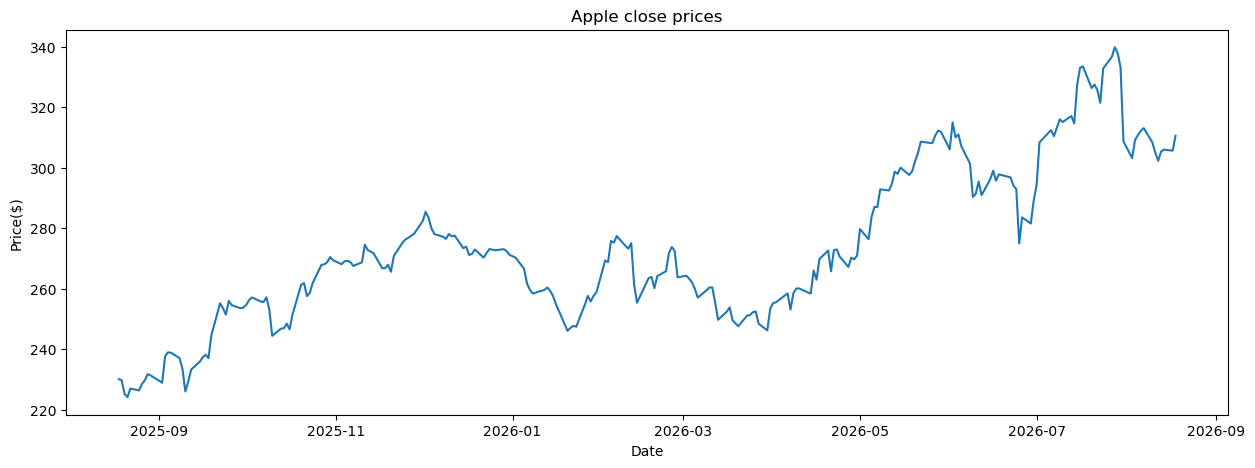

In [3]:
plt.figure(figsize=(15,5))
plt.plot(apple_close_price)
plt.title("Apple close prices")
plt.xlabel("Date")
plt.ylabel("Price($)")
plt.show()

In [4]:
apple_daily_return=apple_close_price.pct_change()

Text(0, 0.5, 'Price($)')

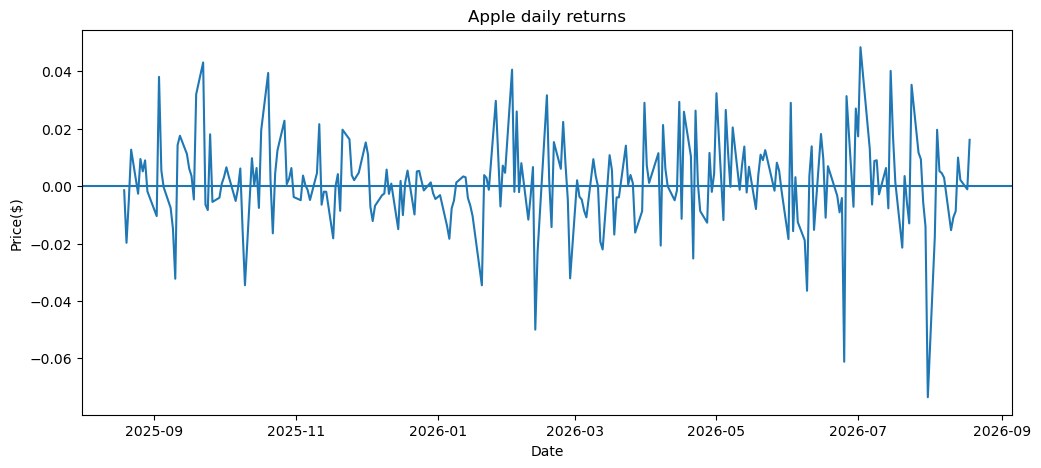

In [5]:
plt.figure(figsize=(12,5))
plt.plot(apple_daily_return)
plt.axhline(0)
plt.title("Apple daily returns")
plt.xlabel("Date")
plt.ylabel("Price($)")

In [6]:
apple_daily_volatility = apple_daily_return.std()
apple_daily_volatility

Ticker
AAPL    0.015761
dtype: float64

In [7]:
apple_annual_volatility = apple_daily_volatility *np.sqrt(252)
apple_annual_volatility

Ticker
AAPL    0.2502
dtype: float64

In [8]:
nvidia = yf.download("NVDA",period="1y")
nvidia_close_price=nvidia["Close"]
nvidia_daily_return = nvidia_close_price.pct_change()
nvidia_daily_volatility= nvidia_daily_return.std()
nvidia_annual_volatility=nvidia_daily_volatility*np.sqrt(252)
nvidia_annual_volatility

[*********************100%***********************]  1 of 1 completed


Ticker
NVDA    0.368858
dtype: float64

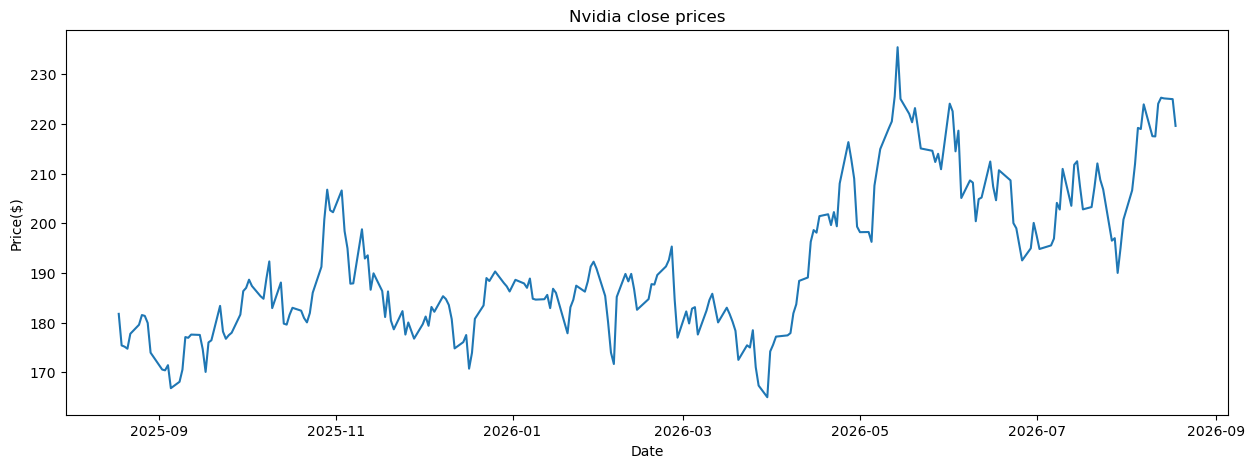

In [9]:
plt.figure(figsize=(15,5))
plt.plot(nvidia_close_price)
plt.title("Nvidia close prices")
plt.xlabel("Date")
plt.ylabel("Price($)")
plt.show()

Text(0, 0.5, 'Price($)')

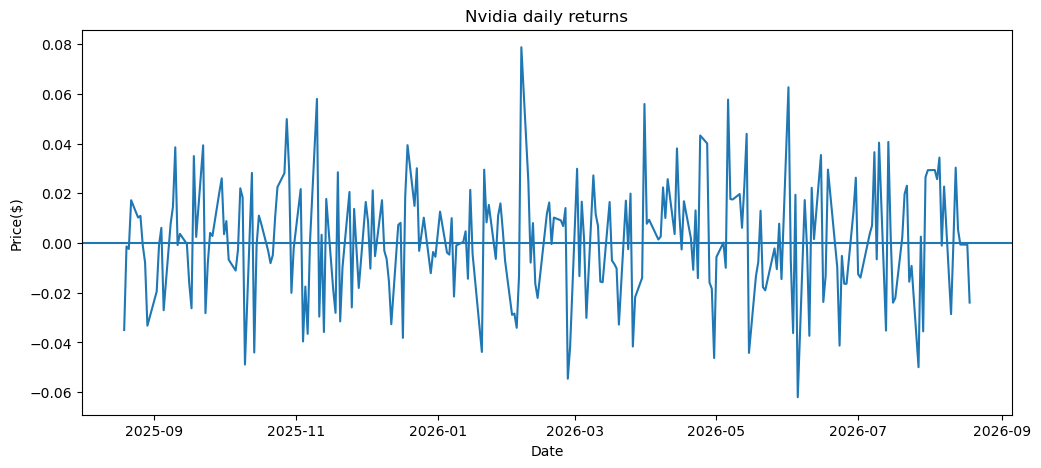

In [10]:
plt.figure(figsize=(12,5))
plt.plot(nvidia_daily_return)
plt.axhline(0)
plt.title("Nvidia daily returns")
plt.xlabel("Date")
plt.ylabel("Price($)")

In [11]:
apple_total_return=(apple_close_price.iloc[-1]-apple_close_price.iloc[0])/apple_close_price.iloc[0]
nvidia_total_return=(nvidia_close_price.iloc[-1]-nvidia_close_price.iloc[0])/nvidia_close_price.iloc[0]
print(apple_total_return,nvidia_total_return)

Ticker
AAPL    0.349873
dtype: float64 Ticker
NVDA    0.208244
dtype: float64


These calculations tell us that Nvidia is more volatile than apple with its annual volatilty being 37% compared to Apple's 25 percent. This is  due to Nvidia being dependent on AI growth and semiconductor stocks. Nvidia has seen sharp increase in its stock price because of the rapid growth and demand of AI but this can also mean its stock could nosedive if AI spending decreased, hence why Nvidia is so volatile. 

In [12]:
nvidia_running_max = nvidia_close_price.cummax()
nvidia_drawdown = (nvidia_close_price- nvidia_running_max)/nvidia_running_max
nvidia_drawdown.min()
nvidia_max_drawdown= nvidia_drawdown.min().iloc[0]
apple_running_max=apple_close_price.cummax()
apple_drawdown= (apple_close_price-apple_running_max)/apple_running_max
apple_max_drawdown= apple_drawdown.min().iloc[0]
print(f"Nvidia max drawdown is {nvidia_max_drawdown}%", f"Apple max drawdown is {apple_max_drawdown}%")

Nvidia max drawdown is -0.20214385493927148% Apple max drawdown is -0.13798523953754416%


In [13]:
correlation= nvidia_daily_return.iloc[:,0].corr(apple_daily_return.iloc[:,0])
correlation

np.float64(0.11608015360691773)

A correlationn of 0.12 suggests a very weak positive relationship between Apple and Nvidia


Text(0, 0.5, 'Apple close price')

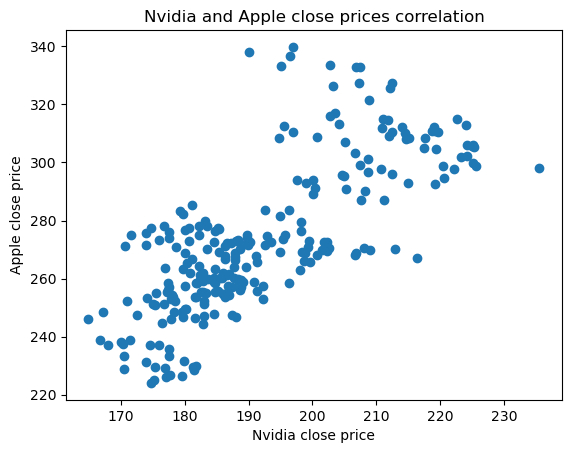

In [14]:
plt.scatter(nvidia_close_price,apple_close_price)
plt.title("Nvidia and Apple close prices correlation")
plt.xlabel("Nvidia close price")
plt.ylabel("Apple close price")

So we can see that Apple and Nvidia are not strongly correlated, this actually is a good thing as investing in these 2 stocks could make your portfolio more diverse. 

In [15]:
risk_free_rate=3.75
apple_sharpe_ratio= (apple_total_return.item()*100-risk_free_rate)/(apple_annual_volatility.item()*100)
nvidia_sharpe_ratio= (nvidia_total_return.item()*100-risk_free_rate)/(nvidia_annual_volatility.item()*100)
print(f"The sharpe ratio for Apple is {apple_sharpe_ratio}",f"The sharpe ratio for Nvidia is {nvidia_sharpe_ratio}")

The sharpe ratio for Apple is 1.248491399240162 The sharpe ratio for Nvidia is 0.46289945332684057


Apple has a sharpe ratio of 1.15 which is higher than Nvidia's 0.57. This implies that Apple had better returns relative to its risk. Whilst Nvidia did perform well, the sharpe ratio tells us that it may not be worth the risk to invest in it. We will investigate this by making a portfolio with these 2 stocks

In [16]:
portfolio_daily_return=0.5*apple_daily_return["AAPL"] + 0.5*nvidia_daily_return["NVDA"]
portfolio_daily_volatility=portfolio_daily_return.std()
portfolio_annual_volatility=(portfolio_daily_volatility*np.sqrt(252)).item()
portfolio_total_return= 0.5*apple_total_return.item() + 0.5*nvidia_total_return.item()
portfolio_sharpe_ratio= (portfolio_total_return*100-risk_free_rate)/(portfolio_annual_volatility*100)
print("The portfolio's annual volatility,total return and sharpe ratio is as follows:", round(portfolio_annual_volatility*100,2) ,round(portfolio_total_return*100,2),round(portfolio_sharpe_ratio,2))

The portfolio's annual volatility,total return and sharpe ratio is as follows: 23.46 27.91 1.03


In [17]:
portfolio_stats = pd.DataFrame({

    "Apple": [

        apple_total_return.item() * 100,

        apple_annual_volatility.item() * 100,

        apple_sharpe_ratio

    ],

    "Nvidia": [

        nvidia_total_return.item() * 100,

        nvidia_annual_volatility.item() * 100,

        nvidia_sharpe_ratio

    ],

    "Portfolio": [

        portfolio_total_return * 100,

        portfolio_annual_volatility * 100,

        portfolio_sharpe_ratio

    ]

}, index=[

    "Total Return (%)",

    "Annual Volatility (%)",

    "Sharpe Ratio"

])

portfolio_stats.round(2)

,Apple,Nvidia,Portfolio
Total Return (%),34.99,20.82,27.91
Annual Volatility (%),25.02,36.89,23.46
Sharpe Ratio,1.25,0.46,1.03


Although Apple had higher returns than the Portfolio,the table shows that the 50/50 portfolio has lower volatility than the stocks individually. The portfolio’s Sharpe ratio of 1.04 indicates a substantially better risk-adjusted performance than Nvidia (0.47), although it remained below Apple’s Sharpe ratio of 1.25. So, overall the portfolio did a good job, and its use would be more emphasised if there were more than 2 stocks. The reason for the lower volatility was because of the weak correlation between the 2 stocks making the portfolio diverse. 